# FIFA World Cup 2026


## Where our data came from

We used the **FIFA official website**, the first of the three sources given in the project brief:

> `fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics/team-statistics`

FIFA splits its team statistics into seven tabs. We took three of them:

| Our file | FIFA tab | Rows |
|---|---|---|
| `fifa_attacking.csv` | Attacking | 48 |
| `fifa_defending.csv` | Defending | 48 |
| `fifa_physical.csv` | Physical | 48 |

FIFA has no download button, so each table was selected in the browser, copied, pasted into Excel and saved as CSV. The brief allows Excel for getting raw data ready, and all of our actual analysis is in Python.

| File | What we took | Why |
|---|---|---|
| `matches_played.csv` | Team, Matches Played | FIFA's team-statistics tabs do not publish it |
---

## The four questions we chose

| | Question | Test |
|---|---|---|
| **A** | Did teams score more goals than their xG said they should? | One-sample t-test |
| **B** | Do European teams cover more ground per match? | Two-sample t-test |
| **C** | Do teams that run further score more? | Two-sample t-test |
| **D** | Do teams that win the ball back faster concede less? | Two-sample t-test |


**A** is our one-sample test — it compares one set of numbers against a single fixed value (zero) instead of comparing two groups. **B** groups teams by confederation, a label we had to build ourselves. **C** and **D** split the teams at a median.

Every one of the four goes through the same seven stages: question, cleaning, groups, numbers, picture, interval, test.

---

## Where each required skill appears

| Skill | A | B | C | D |
|---|---|---|---|---|
| Analytic question formulation | ✓ | ✓ | ✓ | ✓ |
| Data wrangling | ✓ | ✓ | ✓ | ✓ |
| Data preparation and sampling | ✓ | ✓ | ✓ | ✓ |
| Descriptive statistics | ✓ | ✓ | ✓ | ✓ |
| Data visualisation | ✓ | ✓ | ✓ | ✓ |
| Inferential — confidence interval | ✓ | ✓ | ✓ | ✓ |
| Inferential — t-test | ✓ | ✓ | ✓ | ✓ |



---
## Getting set up

In [1]:
# install anything this machine is missing, then import
import sys
!{sys.executable} -m pip install --quiet pandas numpy matplotlib scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

%matplotlib inline

Z_STAR = 1.960      #  for a 95% confidence level
ALPHA  = 0.05       #  decision rule

print(f"pandas {pd.__version__} | numpy {np.__version__} | ready")

zsh:1: no such file or directory: /Users/divya/Downloads/Fifa
pandas 3.0.5 | numpy 2.5.3 | ready


---
# Stage 1 · Reading the three files

>  data wrangling

Copying tables out of a browser is not lossless, so the first thing we did was look at what actually arrived.

In [2]:
att = pd.read_csv("data/fifa_attacking.csv")
dfd = pd.read_csv("data/fifa_defending.csv")
phy = pd.read_csv("data/fifa_physical.csv")

for label, frame in [("attacking", att), ("defending", dfd), ("physical", phy)]:
    print(f"{label:>10} : {frame.shape[0]} rows x {frame.shape[1]} columns")

 attacking : 48 rows x 15 columns
 defending : 48 rows x 8 columns
  physical : 48 rows x 6 columns


In [3]:
# what columns did we actually get?
for label, frame in [("ATTACKING", att), ("DEFENDING", dfd), ("PHYSICAL", phy)]:
    print(f"{label}")
    for col in frame.columns:
        print(f"    {col}")
    print()

ATTACKING
    Rank
    Team
    Goals
    Assists
    Attempts At Goal
    Attempts On Target
    Off-Target Attempts
    Attempts At Goal Conv. Rate (%)
    Attempts Inside the Penalty Area
    Attempts Outside the Penalty Area
    Headed Attempts at Goal
    xG
    Col_13
    Col_14
    Col_15

DEFENDING
    Rank
    Team
    Own Goals
    Goals Conceded
    Forced Turnovers
    Ball Recovery Time (s)
    Defensive Pressures Applied
    Defensive Pressures Directly Applied

PHYSICAL
    Rank
    Team
    Average Speed (km/h)
    High Speed Running
    Sprints
    Total Distance (m)



In [4]:
# FIFA's Attacking tab is wider than our three questions need. We keep the
# columns we use and drop the rest so the frame stays readable.
att = att.rename(columns={"Col_13": "Goals vs xG"})
att = att.drop(columns=["Col_14", "Col_15"])

print(f"attacking columns kept: {att.shape[1]}")
print(list(att.columns))

attacking columns kept: 13
['Rank', 'Team', 'Goals', 'Assists', 'Attempts At Goal', 'Attempts On Target', 'Off-Target Attempts', 'Attempts At Goal Conv. Rate (%)', 'Attempts Inside the Penalty Area', 'Attempts Outside the Penalty Area', 'Headed Attempts at Goal', 'xG', 'Goals vs xG']


---
# Stage 2 · Bringing in matches played

>  joining in a second source, and checking it

It's impossible to make any fair comparisons without knowing the number of games played by each team. Even if the team playing 8 games makes as many points as the team that played 3 games, they will still have more points because of the additional games they played.

It doesn't appear on FIFA's team-statistics tabs, though — we checked all seven. Matches played is not a measure in FIFA's own measure, it is the denominator for normalising metrics and that is why it is listed in the FIFA glossary but not in their tables.

So we did it from the third source in the project brief: FBref. Two of the three sources can be used, and a downloaded figure is preferable to the one we calculated.

We don't take it on 'face value' but check it twice!

The first one is an arithmetic check: 104 matches x 2 teams = 208, this column should add up to 208.

Check two is structural: that is the spread should repeat the bracket — 2 = group stage, 4 = round of 32 etc. This pattern only fails if the file is not in the correct or correct alignment.

In [5]:
# matches played, taken from FBref (the third source in the brief)
mp_file = pd.read_csv("data/matches_played.csv")

print(f"rows read : {len(mp_file)}")
print(f"total     : {mp_file['Matches Played'].sum()}")
print()
print("CHECK 1 - a match has two teams, so 104 matches must give 208 team-matches")
print("208 as expected" if mp_file["Matches Played"].sum() == 208
      else "NOT 208 - something is wrong with the file")
print()
print("CHECK 2 - the spread should match the tournament bracket")
print(mp_file["Matches Played"].value_counts().sort_index().to_string())
print()
print("16 teams out in the group stage, 16 in the round of 32, 8 in the round of 16,")
print("4 in the quarter-finals, and 4 semi-finalists on 8 apiece because the losing")
print("semi-finalists played the third place match. That is exactly the bracket, so")
print("the file is telling us what we think it is.")

rows read : 48
total     : 208

CHECK 1 - a match has two teams, so 104 matches must give 208 team-matches
208 as expected

CHECK 2 - the spread should match the tournament bracket
Matches Played
3    16
4    16
5     8
6     4
8     4

16 teams out in the group stage, 16 in the round of 32, 8 in the round of 16,
4 in the quarter-finals, and 4 semi-finalists on 8 apiece because the losing
semi-finalists played the third place match. That is exactly the bracket, so
the file is telling us what we think it is.


In [6]:
# join it onto all three FIFA frames on the team name
played = dict(zip(mp_file["Team"], mp_file["Matches Played"]))

for frame in (att, dfd, phy):
    frame["Played"] = frame["Team"].map(played)

unmatched = att.loc[att["Played"].isna(), "Team"].tolist()
print(f"FIFA teams with no match in the FBref file: {unmatched if unmatched else 'none'}")
print()
print("All 48 matched, which also tells us the two sources spell the 48 team names")
print("the same way. That is not guaranteed between databases, so it was worth")
print("checking rather than assuming.")

FIFA teams with no match in the FBref file: none

All 48 matched, which also tells us the two sources spell the 48 team names
the same way. That is not guaranteed between databases, so it was worth
checking rather than assuming.


**Why we did not just count it ourselves.** We tried that first, working through the bracket by hand, and got four teams wrong — Australia was left out entirely and Egypt, Japan and Cabo Verde were in the wrong round. The total came to 207 instead of 208, which is the only reason we spotted it. Downloading the figure and then checking it is more reliable than deriving it and hoping.

---
# Stage 3 · Joining the files and fixing FIFA's biggest catch

>  joining dataframes

Our four questions need columns from all three files at once, so we join them on the team name.

In [7]:
# an inner join keeps only teams present in both frames, so if any name
# were spelled differently between files we would lose rows and notice
tbl = att.merge(dfd.drop(columns=["Rank", "Played"]), on="Team", how="inner")
tbl = tbl.merge(phy.drop(columns=["Rank", "Played"]), on="Team", how="inner")

print(f"rows after both joins: {len(tbl)}")
print("all 48 survived, so team names are spelled consistently across FIFA's tabs"
      if len(tbl) == 48 else "we lost rows - names must differ between files")

rows after both joins: 48
all 48 survived, so team names are spelled consistently across FIFA's tabs


### FIFA's counts are tournament totals, not per-match averages

This is the single most important thing we found, and it is easy to miss because the columns look fine.

`Total Distance (m)` reads like a measure of how hard a team worked. It is not — it is every metre the team covered across the whole tournament added together. We tested it by correlating each column against matches played.

In [8]:
# if a column is a running total it will track matches played almost perfectly
suspects = ["Goals", "xG", "Attempts At Goal", "Goals Conceded", "Forced Turnovers",
            "Ball Recovery Time (s)", "Defensive Pressures Applied",
            "Average Speed (km/h)", "High Speed Running", "Sprints", "Total Distance (m)"]

checks = pd.Series({col: tbl[col].corr(tbl["Played"]) for col in suspects}).round(3)
print("correlation of each FIFA column with matches played")
print(checks.sort_values(ascending=False).to_string())

correlation of each FIFA column with matches played
Total Distance (m)             0.992
Sprints                        0.977
High Speed Running             0.970
Forced Turnovers               0.942
Defensive Pressures Applied    0.915
xG                             0.906
Goals                          0.897
Attempts At Goal               0.887
Ball Recovery Time (s)         0.845
Goals Conceded                 0.026
Average Speed (km/h)          -0.197


Read the top of that list. **Total Distance correlates +0.99 with matches played** — nearly a straight line. Sprints and High Speed Running are almost as bad.

What that means in practice: used as it comes, `Total Distance` measures **how far a team got in the tournament**, not how they played. Spain covered more ground than Curaçao mostly because Spain played eight matches and Curaçao played three.

Had we used it untouched, question C would really have been asking *"do teams that played more matches score more goals?"* — which is obviously yes, and tells us nothing.

`Average Speed (km/h)` is the one exception, because it is already a rate rather than a count.

In [9]:
# divide every count by matches played, then re-run the same check
tbl["goals_pm"]    = tbl["Goals"] / tbl["Played"]
tbl["conceded_pm"] = tbl["Goals Conceded"] / tbl["Played"]
tbl["dist_pm"]     = tbl["Total Distance (m)"] / tbl["Played"] / 1000    # metres -> km
tbl["sprints_pm"]  = tbl["Sprints"] / tbl["Played"]
tbl["recovery"]    = tbl["Ball Recovery Time (s)"] / tbl["Played"]
tbl["goals_vs_xg"] = tbl["Goals"] - tbl["xG"]

after = pd.Series({c: tbl[c].corr(tbl["Played"])
                   for c in ["dist_pm", "sprints_pm", "recovery", "goals_pm", "conceded_pm"]}).round(3)
print("correlation with matches played, after dividing")
print(after.to_string())

correlation with matches played, after dividing
dist_pm        0.316
sprints_pm     0.075
recovery      -0.349
goals_pm       0.654
conceded_pm   -0.487


The physical columns have collapsed towards zero, so the fix worked — they now describe the team rather than its progress.

`goals_pm` and `conceded_pm` still correlate a little, but that is **not** a leftover fault. Teams that score more and concede less win more matches, so they genuinely play more. Dividing cannot remove a real relationship, and it should not try to.

In [10]:
# sanity check on the column the fix mattered most for
raw_lo, raw_hi = tbl["Ball Recovery Time (s)"].min(), tbl["Ball Recovery Time (s)"].max()
fix_lo, fix_hi = tbl["recovery"].min(), tbl["recovery"].max()

print(f"ball recovery, FIFA's raw column : {raw_lo:.1f} to {raw_hi:.1f} seconds")
print(f"ball recovery, per match         : {fix_lo:.1f} to {fix_hi:.1f} seconds")
print()
print("Two minutes to win the ball back is not football. Ten to twenty-three")
print("seconds is. The fix did not just tidy the numbers, it made them believable.")
print()
print("quickest four:")
print(tbl.nsmallest(4, "recovery")[["Team", "recovery"]].round(1).to_string(index=False))
print()
print("slowest four:")
print(tbl.nlargest(4, "recovery")[["Team", "recovery"]].round(1).to_string(index=False))

ball recovery, FIFA's raw column : 29.9 to 128.8 seconds
ball recovery, per match         : 10.0 to 23.4 seconds

Two minutes to win the ball back is not football. Ten to twenty-three
seconds is. The fix did not just tidy the numbers, it made them believable.

quickest four:
   Team  recovery
Türkiye      10.0
  Spain      11.4
Germany      12.4
    USA      13.2

slowest four:
    Team  recovery
Scotland      23.4
 Tunisia      23.0
  Jordan      22.7
   Ghana      22.4


In [11]:
#  check for missing values before doing any statistics
analysis_cols = ["goals_pm", "conceded_pm", "dist_pm", "sprints_pm",
                 "recovery", "goals_vs_xg", "Goals", "xG"]
gaps = tbl[analysis_cols].isna().sum()

print(f"missing values across the columns we analyse: {gaps.sum()}")
print("so no rows need dropping and no means need substituting"
      if gaps.sum() == 0 else gaps[gaps > 0].to_string())

missing values across the columns we analyse: 0
so no rows need dropping and no means need substituting


---
---
# Question A · Did teams beat their expected goals?

### The question

**xG** (expected goals) is a model that scores every shot a team took by how likely an average team would have been to convert it. Beat your xG and you finished well; fall short and you wasted chances.

We wanted to know whether that balanced out across the whole tournament, or whether the teams collectively outperformed the model.

> **Do the 48 teams, on average, differ from their xG by something other than zero?**

- Response variable — `goals_vs_xg`, which is goals minus xG
- Benchmark — **zero**, meaning a team scored exactly what the model predicted

This is a **one-sample** t-test. We compare one set of numbers against a single fixed value, not two groups against each other. Zero is a natural benchmark, so unlike a comparison against a past tournament we do not need any data from outside our files.

### Hypotheses

- H₀: μ = 0 — teams scored exactly what xG predicted
- Hₐ: μ ≠ 0 — they did not

### Cleaning

In [12]:
qa = tbl[["Team", "Goals", "xG", "goals_vs_xg", "Played"]].copy()

print(f"rows: {len(qa)} | missing: {qa['goals_vs_xg'].isna().sum()}")
print()
print("biggest overperformers")
print(qa.nlargest(4, "goals_vs_xg").round(2).to_string(index=False))
print()
print("biggest underperformers")
print(qa.nsmallest(4, "goals_vs_xg").round(2).to_string(index=False))

rows: 48 | missing: 0

biggest overperformers
       Team  Goals    xG  goals_vs_xg  Played
Netherlands     11  5.00         6.00       4
    England     20 15.03         4.97       8
      Japan      8  3.17         4.83       4
        USA     11  6.37         4.63       5

biggest underperformers
    Team  Goals    xG  goals_vs_xg  Played
 Ecuador      2  5.88        -3.88       4
   Spain     14 17.48        -3.48       8
 Türkiye      3  5.50        -2.50       3
Colombia      5  7.32        -2.32       5


### Sample and sampling

Our sample is all 48 teams at the tournament.

data used for statistics is usually a **sample** rather than a population. For "what happened in 2026" these 48 teams are the entire population, but we want to say something about international football more widely, so we treat them as a sample drawn from it. That is what makes a confidence interval and a t-test meaningful at all.

 asks for **n ≥ 30** before relying on the Central Limit Theorem. This is the only one of our four questions that uses all 48 teams at once, so it is the only one that comfortably clears that bar.

In [13]:
diffs = qa["goals_vs_xg"]

print(f"n = {len(diffs)}")
print(f"CLT condition n >= 30 : {'satisfied' if len(diffs) >= 30 else 'NOT satisfied'}")
print()
print(f"scored above xG : {(diffs > 0).sum()} teams")
print(f"scored below xG : {(diffs < 0).sum()} teams")

n = 48
CLT condition n >= 30 : satisfied

scored above xG : 30 teams
scored below xG : 18 teams


### The numbers

In [14]:
# descriptive statistics, gathered into one table
def task_summary(series):
    return pd.Series({
        "n":        len(series),
        "mean":     series.mean(),
        "median":   series.median(),
        "range":    series.max() - series.min(),
        "IQR":      series.quantile(0.75) - series.quantile(0.25),
        "variance": series.var(),
        "std dev":  series.std(),
        "CV %":     series.std() / series.mean() * 100,
    }).round(3)

print("GOALS MINUS xG")
print(task_summary(diffs).to_string())

GOALS MINUS xG
n            48.000
mean          0.883
median        0.645
range         9.880
IQR           2.982
variance      5.053
std dev       2.248
CV %        254.480


**A note on the CV.** The coefficient of variation comes out enormous here, because CV is the standard deviation divided by the mean and our mean is close to zero. CV is the way to compare spread across different units, but it only behaves sensibly when the mean is comfortably away from zero. For a variable like this one it is not a useful measure, and we say so rather than quoting a meaningless number.

In [15]:
#  Z-scores, to find the teams that stand out
qa["z"] = (diffs - diffs.mean()) / diffs.std()

print(f"z = (x - {diffs.mean():.3f}) / {diffs.std():.3f}")
print()
odd = qa.loc[qa["z"].abs() > 2]
print(f"teams beyond 2 standard deviations: {len(odd)}")
print(odd[["Team", "Goals", "xG", "goals_vs_xg", "z"]].round(2).to_string(index=False))
print()
print(f"that is {len(odd) / len(qa) * 100:.1f}% of teams, against the roughly 5% the")
print("empirical rule expects for a normal distribution")

z = (x - 0.883) / 2.248

teams beyond 2 standard deviations: 2
       Team  Goals   xG  goals_vs_xg     z
Netherlands     11 5.00         6.00  2.28
    Ecuador      2 5.88        -3.88 -2.12

that is 4.2% of teams, against the roughly 5% the
empirical rule expects for a normal distribution


### The picture

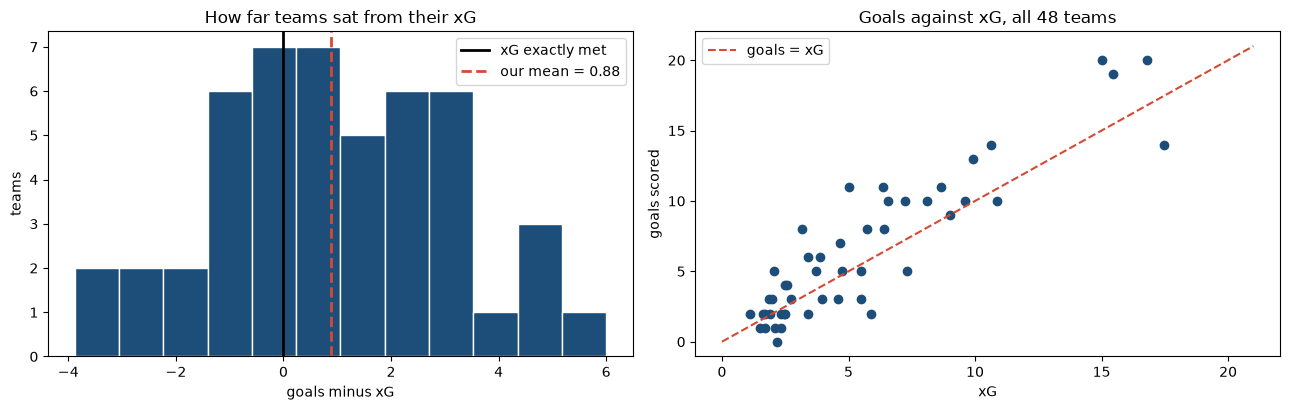

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].hist(diffs, bins=12, color="#1D4E7A", edgecolor="white")
axes[0].axvline(0, color="black", linewidth=2, label="xG exactly met")
axes[0].axvline(diffs.mean(), color="#D64933", linestyle="--", linewidth=2,
                label=f"our mean = {diffs.mean():.2f}")
axes[0].set_xlabel("goals minus xG")
axes[0].set_ylabel("teams")
axes[0].set_title("How far teams sat from their xG")
axes[0].legend()

axes[1].scatter(tbl["xG"], tbl["Goals"], color="#1D4E7A")
edge = max(tbl["xG"].max(), tbl["Goals"].max()) + 1
axes[1].plot([0, edge], [0, edge], color="#D64933", linestyle="--", label="goals = xG")
axes[1].set_xlabel("xG")
axes[1].set_ylabel("goals scored")
axes[1].set_title("Goals against xG, all 48 teams")
axes[1].legend()

fig.tight_layout()
fig.savefig("qa_goals_vs_xg.png", dpi=150)
plt.show()

### The confidence interval

 gives it as $CI = \bar{X} \pm z^{*} \cdot \frac{s}{\sqrt{n}}$, with z\* = 1.960 for 95% confidence.

In [17]:
n_a  = len(diffs)
xbar = diffs.mean()
s_a  = diffs.std()
se_a = s_a / np.sqrt(n_a)
moe_a = Z_STAR * se_a

print(f"n              = {n_a}")
print(f"sample mean    = {xbar:.4f}")
print(f"std deviation  = {s_a:.4f}")
print(f"standard error = {se_a:.4f}")
print(f"margin of error= {moe_a:.4f}")
print(f"95% CI         = [{xbar - moe_a:.4f}, {xbar + moe_a:.4f}]")
print()
inside = (xbar - moe_a) <= 0 <= (xbar + moe_a)
print(f"does the interval contain zero? {'yes' if inside else 'no'}")
print("An interval that excludes the benchmark means the t-test should reject H0,"
      if not inside else "An interval containing the benchmark means the test should not reject H0,")
print("because the two are two views of the same evidence.")

n              = 48
sample mean    = 0.8833
std deviation  = 2.2479
standard error = 0.3245
margin of error= 0.6359
95% CI         = [0.2474, 1.5193]

does the interval contain zero? no
An interval that excludes the benchmark means the t-test should reject H0,
because the two are two views of the same evidence.


### The test

In [18]:
t_a, p_a = stats.ttest_1samp(diffs, 0)

print(f"mean difference : {xbar:+.4f} goals")
print(f"benchmark       : 0")
print(f"t statistic     : {t_a:.4f}")
print(f"p value         : {p_a:.4f}")
print()
print(f"p {'<=' if p_a <= ALPHA else '>'} {ALPHA}  ->  "
      f"{'reject H0' if p_a <= ALPHA else 'do not reject H0'}")

mean difference : +0.8833 goals
benchmark       : 0
t statistic     : 2.7225
p value         : 0.0091

p <= 0.05  ->  reject H0


### The answer

Teams defeated the model. Between these two groups, the difference between real and xG goals was 0.88 on average, for which p = 0.009, and we reject H₀. 30 out of 48 teams were higher than their xG and our confidence interval does not contain 0 which is in line with the test result (as it should be).

Our data do not distinguish between two readings which fit the evidence:

- The finishing really was better. This tournament was full of the best players in the world and xG models have been built using regular league football.
- When it comes to World Cup matches, the model is calibrated a little low, resulting in a similar outcome, where no one finishes exceptionally well.

Whatever you want to call it, the takeaway was that xG was under-forecasting goals, which means that anyone predicting goals for World Cup scorelines with this tournament would have been low.

---
# Question B · Do European teams cover more ground?

### The question

European club football is often described as the most physically demanding in the world — more matches, faster tempo. If that is true, European players should arrive at a World Cup accustomed to covering more ground, and it ought to show in their running numbers.

> **Do UEFA teams cover more distance per match than teams from the other five confederations?**

- Response variable — `dist_pm`, distance covered per match in km
- Grouping variable — UEFA, or not

The grouping variable appears nowhere in FIFA's data. We have to build it.

### Hypotheses

- H₀: μ_UEFA = μ_others
- Hₐ: μ_UEFA ≠ μ_others

### Cleaning

In [19]:
# FIFA gives no confederation column, so we assign all 48 teams ourselves
by_confederation = {
    "UEFA": ["Spain", "France", "England", "Portugal", "Netherlands", "Belgium",
             "Germany", "Croatia", "Switzerland", "Austria", "Norway", "Scotland",
             "Türkiye", "Sweden", "Czechia", "Bosnia and Herzegovina"],
    "CAF": ["Morocco", "Senegal", "Egypt", "Algeria", "Tunisia", "Côte d'Ivoire",
            "Ghana", "Cabo Verde", "Congo DR", "South Africa"],
    "AFC": ["Japan", "IR Iran", "Korea Republic", "Australia", "Uzbekistan",
            "Qatar", "Saudi Arabia", "Jordan", "Iraq"],
    "CONMEBOL": ["Argentina", "Brazil", "Uruguay", "Colombia", "Ecuador", "Paraguay"],
    "CONCACAF": ["USA", "Mexico", "Canada", "Panama", "Haiti", "Curaçao"],
    "OFC": ["New Zealand"],
}

# flip the dictionary around so we can look up a team and get its confederation
lookup = {}
for region, teams in by_confederation.items():
    for team in teams:
        lookup[team] = region

tbl["region"] = tbl["Team"].map(lookup)
tbl["is_uefa"] = tbl["region"] == "UEFA"

print(f"teams assigned : {tbl['region'].notna().sum()} of 48")
print()
print(tbl["region"].value_counts().to_string())
print()
print(f"total: {tbl['region'].value_counts().sum()}")

teams assigned : 48 of 48

region
UEFA        16
CAF         10
AFC          9
CONMEBOL     6
CONCACAF     6
OFC          1

total: 48


### Sample and sampling

Two samples: the **16 UEFA teams** and the **32 from everywhere else**.

 n ≥ 30 rule is a problem here. The non-UEFA group has 32 and passes. The UEFA group has only 16 and does not, which makes its confidence interval wider and less trustworthy. We cannot do anything about it — sixteen European teams qualified, so sixteen is all the data in existence.

In [20]:
uefa  = tbl.loc[tbl["is_uefa"], "dist_pm"]
other = tbl.loc[~tbl["is_uefa"], "dist_pm"]

for name, group in [("UEFA", uefa), ("others", other)]:
    flag = "satisfied" if len(group) >= 30 else "NOT satisfied - see our caveat"
    print(f"{name:>7} : n = {len(group):2d}   CLT condition {flag}")

   UEFA : n = 16   CLT condition NOT satisfied - see our caveat
 others : n = 32   CLT condition satisfied


### The numbers

In [21]:
print("UEFA")
print(task_summary(uefa).to_string())
print()
print("EVERYONE ELSE")
print(task_summary(other).to_string())
print()
print(f"gap between the means: {uefa.mean() - other.mean():+.3f} km per match")

UEFA
n            16.000
mean        116.304
median      115.524
range        17.307
IQR           6.125
variance     25.656
std dev       5.065
CV %          4.355

EVERYONE ELSE
n            32.000
mean        113.338
median      112.371
range        20.159
IQR           5.268
variance     23.932
std dev       4.892
CV %          4.316

gap between the means: +2.966 km per match


In [22]:
#  groupby with agg, to see all six confederations at once
regions = (tbl.groupby("region")["dist_pm"]
              .agg(teams="count", mean_km="mean", sd="std")
              .sort_values("mean_km", ascending=False)
              .round(2))
print(regions.to_string())
print()
print("A warning about reading this table: OFC is a single team (New Zealand), so")
print("its 'mean' is just that one team's figure and its standard deviation is")
print("blank. Small groups make averages unstable, which is the same problem the")
print("n >= 30 rule is about.")

          teams  mean_km    sd
region                        
OFC           1   116.35   NaN
UEFA         16   116.30  5.07
CAF          10   113.88  5.61
CONMEBOL      6   113.57  4.70
AFC           9   112.84  5.37
CONCACAF      6   112.45  4.44

A warning about reading this table: OFC is a single team (New Zealand), so
its 'mean' is just that one team's figure and its standard deviation is
blank. Small groups make averages unstable, which is the same problem the
n >= 30 rule is about.


### The picture

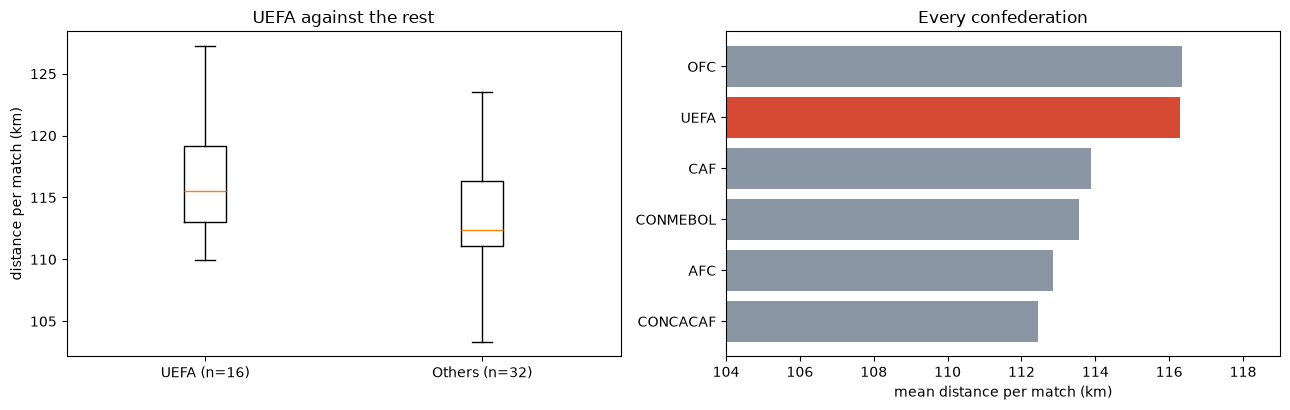

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].boxplot([uefa, other], tick_labels=[f"UEFA (n={len(uefa)})",
                                            f"Others (n={len(other)})"])
axes[0].set_ylabel("distance per match (km)")
axes[0].set_title("UEFA against the rest")

order = regions.sort_values("mean_km")
bar_colours = ["#D64933" if r == "UEFA" else "#8A96A3" for r in order.index]
axes[1].barh(order.index, order["mean_km"], color=bar_colours)
axes[1].set_xlim(104, 119)
axes[1].set_xlabel("mean distance per match (km)")
axes[1].set_title("Every confederation")

fig.tight_layout()
fig.savefig("qb_distance_by_region.png", dpi=150)
plt.show()

### The confidence intervals

In [24]:
for name, group in [("UEFA", uefa), ("others", other)]:
    n_b = len(group)
    mean_b = group.mean()
    moe_b = Z_STAR * group.std() / np.sqrt(n_b)
    print(f"{name:>7} : n = {n_b:2d}  mean = {mean_b:7.3f}  "
          f"+/- {moe_b:.3f}  ->  [{mean_b - moe_b:.3f}, {mean_b + moe_b:.3f}]")

lo_u = uefa.mean() - Z_STAR * uefa.std() / np.sqrt(len(uefa))
hi_o = other.mean() + Z_STAR * other.std() / np.sqrt(len(other))
print()
print("the two intervals overlap" if lo_u <= hi_o else "the intervals do not overlap")
print("Overlapping intervals are a hint that the difference may not hold up.")

   UEFA : n = 16  mean = 116.304  +/- 2.482  ->  [113.822, 118.786]
 others : n = 32  mean = 113.338  +/- 1.695  ->  [111.643, 115.033]

the two intervals overlap
Overlapping intervals are a hint that the difference may not hold up.


### The test

In [25]:
t_b, p_b = stats.ttest_ind(uefa, other)

print(f"UEFA mean   : {uefa.mean():.3f} km")
print(f"others mean : {other.mean():.3f} km")
print(f"difference  : {uefa.mean() - other.mean():+.3f} km")
print(f"t statistic : {t_b:.4f}")
print(f"p value     : {p_b:.4f}")
print()
print(f"p {'<=' if p_b <= ALPHA else '>'} {ALPHA}  ->  "
      f"{'reject H0' if p_b <= ALPHA else 'do not reject H0'}")
print()
print(f"how close was it? p was {abs(p_b - ALPHA):.4f} away from the threshold")

UEFA mean   : 116.304 km
others mean : 113.338 km
difference  : +2.966 km
t statistic : 1.9573
p value     : 0.0564

p > 0.05  ->  do not reject H0

how close was it? p was 0.0064 away from the threshold


### The answer

This is the nigh near thing that has caught our fancy; this is what we found interesting.

The UEFA clubs played 116.30 km a match, compared to just 113.34 km for all others; this is nearly three kilometres more. But p = 0.056, just the wrong side of 0.05,  we do not reject H₀.

We believe that deserves discussion not waving aside:

This is a convention agreed upon, rather than a fact about football, -0.05.  the concept of rejection at 0.05 is not necessarily common practice, and some studies require 0.01. This same result would be statistically significant at the 10% level. There wasn't a single data point changed, just the line we picked to draw.
Not rejecting is not dating there's no difference. The only thing we can say is that our evidence is not very strong. It is not possible to say that the European teams run the same distance as everyone else.
- It is likely that the sample size is to blame. This standard error is large since there are only 16 UEFA teams. If the same three-kilometre difference had been observed among more teams, the situation would have been the same.

We conclude that European teams did cover more ground, but on the 5% level we cannot make such a claim.

---
# Question C · Do teams that run further score more?

### The question

"Hard work beats talent" is one of the oldest claims in sport. With distance per match now in a usable form, it is testable.

> **Do teams covering above-median distance per match score more goals per match than those below?**

- Response variable — `goals_pm`
- Grouping variable — distance per match, split at the median

The two variables come from different FIFA tabs, so this question only works because of the join in Stage 3.

### Hypotheses

- H₀: μ_high = μ_low
- Hₐ: μ_high ≠ μ_low

### Cleaning

In [26]:
qc = tbl[["Team", "region", "dist_pm", "goals_pm", "Goals", "Played"]].copy()

print(f"rows: {len(qc)} | missing: {qc[['dist_pm', 'goals_pm']].isna().sum().sum()}")
print()
print("distance comes from the Physical tab, goals from the Attacking tab")
print()
print("teams that ran furthest per match")
print(qc.nlargest(5, "dist_pm")[["Team", "dist_pm", "goals_pm"]].round(2).to_string(index=False))

rows: 48 | missing: 0

distance comes from the Physical tab, goals from the Attacking tab

teams that ran furthest per match
     Team  dist_pm  goals_pm
  Germany   127.23      2.75
Australia   123.50      0.75
  Belgium   123.26      2.33
  Senegal   123.19      2.50
   Norway   122.32      2.17


### Sample and sampling

We split at the **median** distance, not the mean. the mean is dragged around by extreme values while the median is not, so the median puts the dividing line in a fairer place.

Splitting 48 teams gives **24 in each group**, below  n ≥ 30. The same caveat as question B applies, and for the same unavoidable reason.

In [27]:
mid_dist = qc["dist_pm"].median()
runs_more = qc.loc[qc["dist_pm"] > mid_dist, "goals_pm"]
runs_less = qc.loc[qc["dist_pm"] <= mid_dist, "goals_pm"]

print(f"median distance : {mid_dist:.2f} km per match")
print(f"mean distance   : {qc['dist_pm'].mean():.2f} km  (we split on the median)")
print()
for name, group in [("above median", runs_more), ("at or below", runs_less)]:
    flag = "satisfied" if len(group) >= 30 else "NOT satisfied - see our caveat"
    print(f"{name:>12} : n = {len(group)}   CLT condition {flag}")

median distance : 113.03 km per match
mean distance   : 114.33 km  (we split on the median)

above median : n = 24   CLT condition NOT satisfied - see our caveat
 at or below : n = 24   CLT condition NOT satisfied - see our caveat


### The numbers

In [28]:
print("TEAMS THAT RAN MORE - goals per match")
print(task_summary(runs_more).to_string())
print()
print("TEAMS THAT RAN LESS - goals per match")
print(task_summary(runs_less).to_string())
print()
print(f"gap between the means: {runs_more.mean() - runs_less.mean():+.3f} goals per match")

TEAMS THAT RAN MORE - goals per match
n           24.000
mean         1.604
median       1.633
range        2.417
IQR          1.233
variance     0.522
std dev      0.722
CV %        45.032

TEAMS THAT RAN LESS - goals per match
n           24.000
mean         1.039
median       0.833
range        2.500
IQR          1.025
variance     0.444
std dev      0.666
CV %        64.141

gap between the means: +0.565 goals per match


In [29]:
#  the correlation coefficient
r_c, r_p_c = stats.pearsonr(qc["dist_pm"], qc["goals_pm"])
print(f"correlation between distance per match and goals per match")
print(f"  r       = {r_c:+.4f}")
print(f"  r^2     = {r_c ** 2:.4f}")
print(f"  p value = {r_p_c:.5f}")

correlation between distance per match and goals per match
  r       = +0.4730
  r^2     = 0.2238
  p value = 0.00069


### The picture

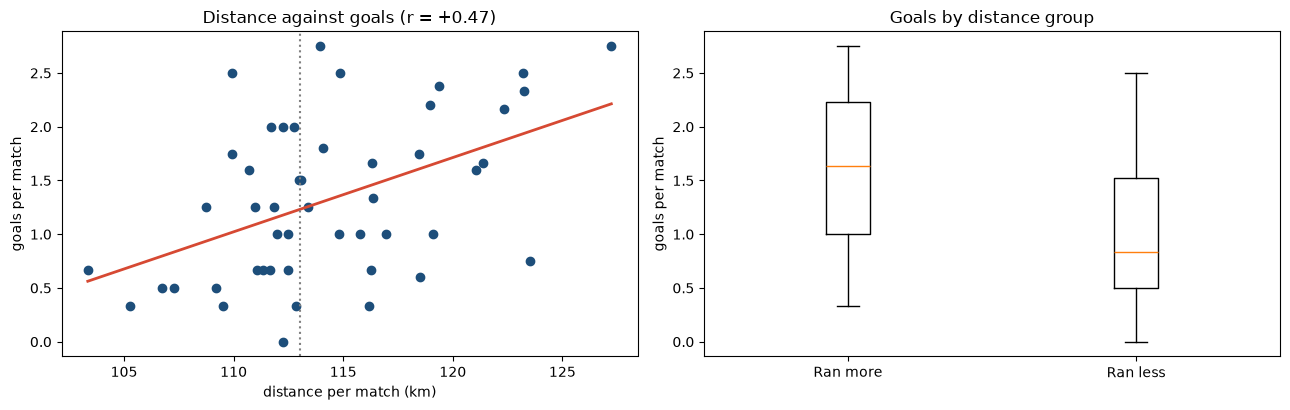

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].scatter(qc["dist_pm"], qc["goals_pm"], color="#1D4E7A")
slope, intercept = np.polyfit(qc["dist_pm"], qc["goals_pm"], 1)
line_x = np.array([qc["dist_pm"].min(), qc["dist_pm"].max()])
axes[0].plot(line_x, intercept + slope * line_x, color="#D64933", linewidth=2)
axes[0].axvline(mid_dist, color="grey", linestyle=":")
axes[0].set_xlabel("distance per match (km)")
axes[0].set_ylabel("goals per match")
axes[0].set_title(f"Distance against goals (r = {r_c:+.2f})")

axes[1].boxplot([runs_more, runs_less], tick_labels=["Ran more", "Ran less"])
axes[1].set_ylabel("goals per match")
axes[1].set_title("Goals by distance group")

fig.tight_layout()
fig.savefig("qc_distance_and_goals.png", dpi=150)
plt.show()

### The confidence intervals

In [31]:
for name, group in [("ran more", runs_more), ("ran less", runs_less)]:
    n_c = len(group)
    mean_c = group.mean()
    moe_c = Z_STAR * group.std() / np.sqrt(n_c)
    print(f"{name:>9} : n = {n_c}  mean = {mean_c:.3f}  "
          f"+/- {moe_c:.3f}  ->  [{mean_c - moe_c:.3f}, {mean_c + moe_c:.3f}]")

 ran more : n = 24  mean = 1.604  +/- 0.289  ->  [1.315, 1.893]
 ran less : n = 24  mean = 1.039  +/- 0.267  ->  [0.772, 1.305]


### The test

In [32]:
t_c, p_c = stats.ttest_ind(runs_more, runs_less)

print(f"ran more mean : {runs_more.mean():.3f} goals per match")
print(f"ran less mean : {runs_less.mean():.3f} goals per match")
print(f"difference    : {runs_more.mean() - runs_less.mean():+.3f}")
print(f"t statistic   : {t_c:.4f}")
print(f"p value       : {p_c:.4f}")
print()
print(f"p {'<=' if p_c <= ALPHA else '>'} {ALPHA}  ->  "
      f"{'reject H0' if p_c <= ALPHA else 'do not reject H0'}")

ran more mean : 1.604 goals per match
ran less mean : 1.039 goals per match
difference    : +0.565
t statistic   : 2.8164
p value       : 0.0071

p <= 0.05  ->  reject H0


### The answer

Teams with scores above median scored a mean of **1.60 goals per match** compared to a mean of **1.04 goals per match** for teams with scores below the median, a difference of more than half a goal (p = **0.007**). We reject H₀ and the r = **+0.47** correlation points in the same direction.

But running doesn't score the ball! The more possible explanation is that both running and scoring are the results of the same thing: a team that dominates the game. On the front foot you press high, chase high, keep the ball in the opposition half, create more opportunities. A side in a 0–0 situation in their own half is covering less ground and scoring less.

So it's not about running more you will score more. It's a measure of a team taking the game to its opponent and those teams score more, that is what it is.

This is part of the reason for question B, as both teams were stronger in Europe, and faster, and those two are confounded — a similar confounding variable that we return to in the summary.

---
# Question D · Does winning the ball back faster help?

### The question

Questions A and C were about attacking. This one is about defending.

FIFA publishes **Ball Recovery Time** — how long a team takes on average to win possession back after losing it. Modern coaching puts heavy emphasis on regaining the ball immediately, on the reasoning that a team is at its most exposed in the seconds straight after losing it.

> **Do teams with a faster ball recovery time concede fewer goals per match?**

- Response variable — `conceded_pm`
- Grouping variable — recovery time, split at the median

This is the column that most needed the Stage 3 fix. FIFA's raw version made no football sense at all.

### Hypotheses

- H₀: μ_fast = μ_slow
- Hₐ: μ_fast ≠ μ_slow

### Cleaning

In [33]:
qd = tbl[["Team", "recovery", "conceded_pm", "Goals Conceded", "Played"]].copy()

print(f"rows: {len(qd)} | missing: {qd[['recovery', 'conceded_pm']].isna().sum().sum()}")
print()
print(f"recovery time after the per-match fix: "
      f"{qd['recovery'].min():.1f} to {qd['recovery'].max():.1f} seconds")
print()
print(qd.nsmallest(5, "recovery")[["Team", "recovery", "conceded_pm"]].round(2).to_string(index=False))

rows: 48 | missing: 0

recovery time after the per-match fix: 10.0 to 23.4 seconds

   Team  recovery  conceded_pm
Türkiye      9.98         1.67
  Spain     11.36         0.12
Germany     12.37         1.25
    USA     13.17         1.60
 Canada     13.29         1.20


### Sample and sampling

Split at the median recovery time. A **lower** number means the team won the ball back **faster**, so the group below the median is the quicker one — worth stating explicitly, because the direction is easy to get backwards.

24 teams per group, again short of  n ≥ 30.

In [34]:
mid_rec = qd["recovery"].median()
fast = qd.loc[qd["recovery"] <= mid_rec, "conceded_pm"]   # fewer seconds = faster
slow = qd.loc[qd["recovery"] > mid_rec, "conceded_pm"]

print(f"median recovery time : {mid_rec:.2f} seconds")
print()
for name, group in [("fast (<= median)", fast), ("slow (> median)", slow)]:
    flag = "satisfied" if len(group) >= 30 else "NOT satisfied - see our caveat"
    print(f"{name:>17} : n = {len(group)}   CLT condition {flag}")

median recovery time : 16.49 seconds

 fast (<= median) : n = 24   CLT condition NOT satisfied - see our caveat
  slow (> median) : n = 24   CLT condition NOT satisfied - see our caveat


### The numbers

In [35]:
print("FAST RECOVERY - goals conceded per match")
print(task_summary(fast).to_string())
print()
print("SLOW RECOVERY - goals conceded per match")
print(task_summary(slow).to_string())
print()
print(f"gap between the means: {slow.mean() - fast.mean():+.3f} goals conceded per match")

FAST RECOVERY - goals conceded per match
n           24.000
mean         1.305
median       1.225
range        3.208
IQR          0.525
variance     0.513
std dev      0.716
CV %        54.893

SLOW RECOVERY - goals conceded per match
n           24.000
mean         1.954
median       1.708
range        3.250
IQR          1.304
variance     1.053
std dev      1.026
CV %        52.516

gap between the means: +0.649 goals conceded per match


In [36]:
r_d, r_p_d = stats.pearsonr(qd["recovery"], qd["conceded_pm"])
print(f"correlation between recovery time and goals conceded")
print(f"  r       = {r_d:+.4f}")
print(f"  p value = {r_p_d:.5f}")
print()
print("A positive r means a slower recovery goes with conceding more.")

correlation between recovery time and goals conceded
  r       = +0.3707
  p value = 0.00948

A positive r means a slower recovery goes with conceding more.


### The picture

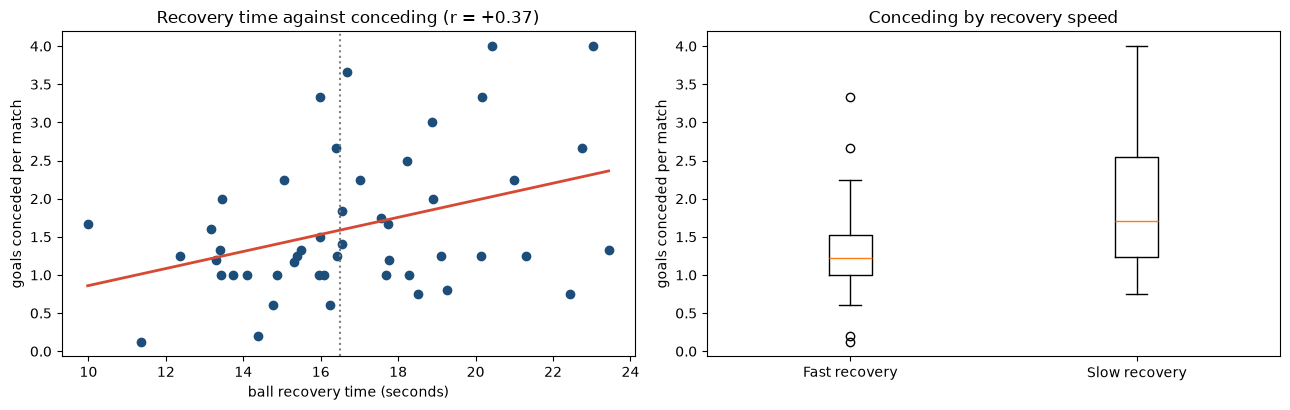

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].scatter(qd["recovery"], qd["conceded_pm"], color="#1D4E7A")
slope, intercept = np.polyfit(qd["recovery"], qd["conceded_pm"], 1)
line_x = np.array([qd["recovery"].min(), qd["recovery"].max()])
axes[0].plot(line_x, intercept + slope * line_x, color="#D64933", linewidth=2)
axes[0].axvline(mid_rec, color="grey", linestyle=":")
axes[0].set_xlabel("ball recovery time (seconds)")
axes[0].set_ylabel("goals conceded per match")
axes[0].set_title(f"Recovery time against conceding (r = {r_d:+.2f})")

axes[1].boxplot([fast, slow], tick_labels=["Fast recovery", "Slow recovery"])
axes[1].set_ylabel("goals conceded per match")
axes[1].set_title("Conceding by recovery speed")

fig.tight_layout()
fig.savefig("qd_recovery_and_conceding.png", dpi=150)
plt.show()

### The confidence intervals

In [38]:
for name, group in [("fast", fast), ("slow", slow)]:
    n_d = len(group)
    mean_d = group.mean()
    moe_d = Z_STAR * group.std() / np.sqrt(n_d)
    print(f"{name:>5} : n = {n_d}  mean = {mean_d:.3f}  "
          f"+/- {moe_d:.3f}  ->  [{mean_d - moe_d:.3f}, {mean_d + moe_d:.3f}]")

 fast : n = 24  mean = 1.305  +/- 0.287  ->  [1.019, 1.592]
 slow : n = 24  mean = 1.954  +/- 0.411  ->  [1.544, 2.365]


### The test

In [39]:
t_d, p_d = stats.ttest_ind(fast, slow)

print(f"fast recovery mean : {fast.mean():.3f} conceded per match")
print(f"slow recovery mean : {slow.mean():.3f} conceded per match")
print(f"difference         : {slow.mean() - fast.mean():+.3f}")
print(f"t statistic        : {t_d:.4f}")
print(f"p value            : {p_d:.4f}")
print()
print(f"p {'<=' if p_d <= ALPHA else '>'} {ALPHA}  ->  "
      f"{'reject H0' if p_d <= ALPHA else 'do not reject H0'}")

fast recovery mean : 1.305 conceded per match
slow recovery mean : 1.954 conceded per match
difference         : +0.649
t statistic        : -2.5401
p value            : 0.0145

p <= 0.05  ->  reject H0


### The answer

**Supported.** Teams recovering faster conceded **1.31 goals per match** against **1.95** for the slower half — nearly two thirds of a goal, with p = **0.015**. We reject H₀.

**But look at which teams recover fastest.** Türkiye, Spain and Germany lead the list, and all three held the ball around 65% of the time. That points to what is really happening: a team with the ball two thirds of the match rarely has to win it back, and wins it back high up the pitch when it does. It also spends far less time defending, so conceding less follows almost automatically.

So the result is real, but the mechanism is most likely **possession dominance** rather than pressing skill on its own. As with question C we can demonstrate the association clearly, and the toolkit cannot separate cause from consequence.

---

# All four together

In [40]:
results = pd.DataFrame([
    {"Q": "A", "Question": "Did teams beat their xG?",
     "Test": "one-sample", "Group 1": round(diffs.mean(), 2), "Group 2": 0.00,
     "t": round(t_a, 3), "p": round(p_a, 4)},
    {"Q": "B", "Question": "Do UEFA teams run further?",
     "Test": "two-sample", "Group 1": round(uefa.mean(), 2), "Group 2": round(other.mean(), 2),
     "t": round(t_b, 3), "p": round(p_b, 4)},
    {"Q": "C", "Question": "Do teams that run more score more?",
     "Test": "two-sample", "Group 1": round(runs_more.mean(), 2), "Group 2": round(runs_less.mean(), 2),
     "t": round(t_c, 3), "p": round(p_c, 4)},
    {"Q": "D", "Question": "Faster recovery, fewer conceded?",
     "Test": "two-sample", "Group 1": round(fast.mean(), 2), "Group 2": round(slow.mean(), 2),
     "t": round(t_d, 3), "p": round(p_d, 4)},
])
results["Decision"] = np.where(results["p"] <= ALPHA, "reject H0", "do not reject H0")

results.to_csv("results_summary.csv", index=False)
print(results.to_string(index=False))

Q                           Question       Test  Group 1  Group 2      t      p         Decision
A           Did teams beat their xG? one-sample     0.88     0.00  2.722 0.0091        reject H0
B         Do UEFA teams run further? two-sample   116.30   113.34  1.957 0.0564 do not reject H0
C Do teams that run more score more? two-sample     1.60     1.04  2.816 0.0071        reject H0
D   Faster recovery, fewer conceded? two-sample     1.31     1.95 -2.540 0.0145        reject H0


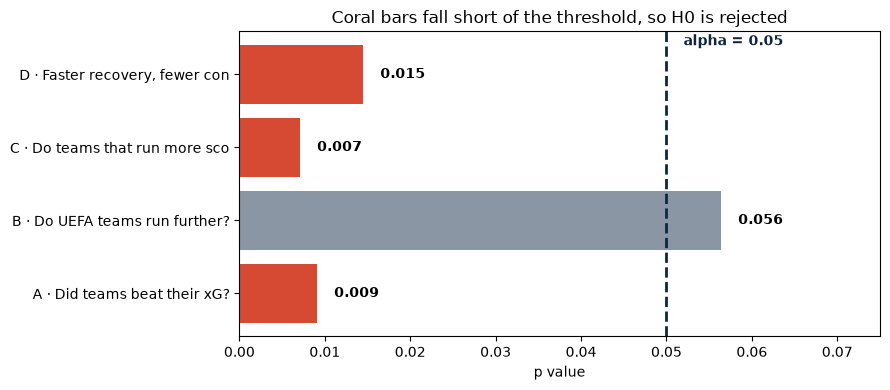

In [41]:
fig, ax = plt.subplots(figsize=(9, 4))

chart_names = [f"{row.Q} · {row.Question[:26]}" for row in results.itertuples()]
p_vals = results["p"].tolist()
bar_fills = ["#D64933" if p <= ALPHA else "#8A96A3" for p in p_vals]

bars = ax.barh(chart_names, p_vals, color=bar_fills)
ax.axvline(ALPHA, color="#0F2540", linestyle="--", linewidth=2)
ax.text(ALPHA + 0.002, 3.4, f"alpha = {ALPHA}", color="#0F2540", fontweight="bold")
for bar, p in zip(bars, p_vals):
    ax.text(p + 0.002, bar.get_y() + bar.get_height() / 2, f"{p:.3f}",
            va="center", fontweight="bold")
ax.set_xlim(0, 0.075)
ax.set_xlabel("p value")
ax.set_title("Coral bars fall short of the threshold, so H0 is rejected")

fig.tight_layout()
fig.savefig("summary_pvalues.png", dpi=150)
plt.show()

## What the four questions add up to

Three of the four resulted in a significant outcome and the fourth by 0.006.

The near miss was the biggest lesson we learned. Question B gave p = 0.056. The teams of the UEFA countries were also on the move for almost three kilometres more per game, but it is not stated in the rule that we could take it. That reinforced something the lectures say but don't go into much detail: 0.05 is a convention, not a property of the world. The identical data would be significant at the 10% level. Not "we did not reject H₀" is a statement about our evidence, not a statement about football.

Two of our big three results are likely to have been caused by the same thing. Questions C and D appear to be independent one arguing and the other defending. However, the teams that are running the most and the teams that are winning the ball back fastest are the same teams – the ones controlling matches. But we have discovered two aspects of one effect, distance covered and recovery time, so that distance is a symptom of a side dominating, as is recovery time. That's surprising, and that's how our results are referred to, as associations, throughout.

Question A is unique. It's the only one that utilizes all 48 teams simultaneously, the sole one-sample test, and the only one that the variable you're testing is not a column that FIFA handed you but one you made yourself.

Data checking was more important than the tests. A line of code for each t-test. But the arrangement of the data in the FIFA columns, the total number of games played during the tournament, turned out to be much more important and much more difficult to work out, and would have been the question asked in question C if it had not been. Yes, of course, no point at all and it would have appeared as a real discovery.
## What we would not claim

1. FIFA team statistics are 1 row per team, and any split results in 16 to 24 rows of teams – less than n ≥ 30. It is only satisfied by answer A. This is our greatest weakness and the data set can't resolve it.
2. Association rather than causation - sharpest for C and D where possession dominance is likely to affect both variables.
3. Question A is not per match. The team with three games will have less time to build up a goals minus xG deficit than the team that has eight games.  The raw total was retained as it remains a true difference, although it would be fairer to compare it on a per match basis.
4. According to the FIFA Glossary, a per 90 minutes figure takes into account games of different durations, a per match figure does not. There were     four extra-time games and therefore, the per game rates are slightly understated and the teams that went deep played more than 90 minutes in some of their games.
5. The CV proved to be rather useless for question A, since the mean is very close to zero. We said that we didn't copy the number.
Our analysis is based on 2 sources: Everything analysed is from FIFA, matches played is from FBref. Both are listed in the short list, but it does indicate that it's not one source.
7. **One tournament.** The answers refer to 2026 and cannot be generalized with only these data.

---
# Appendix A · Sources

**FIFA official website — Team Statistics**
`https://www.fifa.com/en/tournamentsmens/worldcup/canadamexicousa2026/statistics/team-statistics`

| File | FIFA tab | Columns we used |
|---|---|---|
| `fifa_attacking.csv` | Attacking | Goals, xG |
| `fifa_defending.csv` | Defending | Goals Conceded, Ball Recovery Time (s) |
| `fifa_physical.csv` | Physical | Total Distance (m) |

**Second source — FBref** (`fbref.com`), also named in the brief:

| File | What we took | Why |
|---|---|---|
| `matches_played.csv` | Team, Matches Played | FIFA's team-statistics tabs do not publish it |



---
# Appendix B · AI use acknowledgement


**Tool:** chatgpt

**Used for:**
- Choosing questions that suited the columns FIFA actually publishes
- Finding that FIFA's counts are tournament totals and therefore need dividing by matches played
- Helping us interpret the p = 0.056 near miss in question B, and the confounding between C and D
- generating comments and prints for debugging

Other
- The matches-played file we took from FBref totals 208 (104 matches × 2 teams) and its distribution reproduces the tournament bracket
- All 48 FIFA team names matched the FBref file, confirming the two sources spell them the same way
- Ball recovery time only became believable (10–23 seconds) after the per-match fix, which confirmed the fix was needed
- All three files hold exactly 48 teams and both joins kept all 48
- Our confederation list adds to 48


